# GoPay Google Play Review - Sentiment Analysis

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `04 - Sentiment Analysis`

This notebook continues from the preprocessing covered in [3-Gopay-Review-Preprocessing.ipynb](https://colab.research.google.com/drive/1Iwg8LQ69nvhEtv6wE4Ou7uM2hySBrhKd?usp=sharing)

## Dataset Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

df_gopay_clean = pd.read_csv('/content/drive/MyDrive/Tugas 1/gopay_reviews_cleandata.csv')
df_gopay_clean.head()

,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_final
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,2026-02-28 15:16:28,0,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",negative,pakai kayak top brimo ket sukses akun saldo ma...,"['pakai', 'kayak', 'top', 'brimo', 'ket', 'suk..."
1,busuk,1,2026-02-28 15:14:08,0,NaN,negative,busuk,['busuk']
2,selalu dapat bonus,5,2026-02-28 15:12:17,0,NaN,positive,bonus,['bonus']
3,"good, kasih donk promonya",5,2026-02-28 15:10:00,0,NaN,positive,good kasih promonya,"['good', 'kasih', 'promonya']"
4,terbaik mendukung bwnget,5,2026-02-28 15:08:01,0,NaN,positive,baik dukung,"['baik', 'dukung']"


In [3]:
df_gopay_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209311 entries, 0 to 209310
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   content        209311 non-null  object
 1   score          209311 non-null  int64 
 2   at             209311 non-null  object
 3   thumbsUpCount  209311 non-null  int64 
 4   replyContent   59158 non-null   object
 5   sentiment      209311 non-null  object
 6   final_text     209311 non-null  object
 7   tokens_final   209311 non-null  object
dtypes: int64(2), object(6)
memory usage: 12.8+ MB


## TextBlob Installation & Sentiment Scoring

In [4]:
!pip install textblob -q

In [5]:
from textblob import TextBlob

# Hitung polarity dan subjectivity dari final_text (teks yang sudah di-preprocessing)
df_gopay_clean['sentiment_polarity'] = df_gopay_clean['final_text'].astype(str).apply(
    lambda x: TextBlob(x).polarity
)
df_gopay_clean['sentiment_subjectivity'] = df_gopay_clean['final_text'].astype(str).apply(
    lambda x: TextBlob(x).subjectivity
)

print('Sentiment polarity dan subjectivity berhasil dihitung.')
df_gopay_clean[['content', 'final_text', 'sentiment_polarity', 'sentiment_subjectivity']].head(5)

Sentiment polarity dan subjectivity berhasil dihitung.


,content,final_text,sentiment_polarity,sentiment_subjectivity
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",pakai kayak top brimo ket sukses akun saldo ma...,0.5,0.5
1,busuk,busuk,0.0,0.0
2,selalu dapat bonus,bonus,0.0,0.0
3,"good, kasih donk promonya",good kasih promonya,0.7,0.6
4,terbaik mendukung bwnget,baik dukung,0.0,0.0


In [6]:
# Sentiment label sudah ada dari preprocessing (berdasarkan score rating)
# Positive: score 4-5 | Neutral: score 3 | Negative: score 1-2
print('Distribusi sentiment label:')
print(df_gopay_clean['sentiment'].value_counts())
print()
print('Proporsi (%):')
print((df_gopay_clean['sentiment'].value_counts(normalize=True) * 100).round(2))

Distribusi sentiment label:
sentiment
positive    141373
negative     58780
neutral       9158
Name: count, dtype: int64

Proporsi (%):
sentiment
positive    67.54
negative    28.08
neutral      4.38
Name: proportion, dtype: float64


In [7]:
df_gopay_clean[['final_text', 'score', 'sentiment_polarity', 'sentiment_subjectivity', 'sentiment']].head(10)

,final_text,score,sentiment_polarity,sentiment_subjectivity,sentiment
0,pakai kayak top brimo ket sukses akun saldo ma...,1,0.5,0.5,negative
1,busuk,1,0.0,0.0,negative
2,bonus,5,0.0,0.0,positive
3,good kasih promonya,5,0.7,0.6,positive
4,baik dukung,5,0.0,0.0,positive
5,token murah,5,0.0,0.0,positive
6,niat ada top etoll mending fasilitas bikin rugi,1,0.5,0.5,negative
7,sok akrab samsung jelek,1,0.0,0.0,negative
8,wallet multifungsi kasih,5,0.0,0.0,positive
9,bantu,5,0.0,0.0,positive


## EDA — Exploratory Data Analysis

In [8]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import warnings
warnings.filterwarnings('ignore')

In [9]:
df_gopay_clean.sample(5)

,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_final,sentiment_polarity,sentiment_subjectivity
204224,"Aplikasinya bagus,memudahkan kita juga buat tr...",5,2023-08-19 03:25:05,1,NaN,positive,bagusmemudahkan transfer gratis transfer banget,"['bagusmemudahkan', 'transfer', 'gratis', 'tra...",0.0,0.0
12988,mantap JD mudah transaksi apa aja,3,2026-01-17 01:08:47,0,NaN,neutral,mantap mudah transaksi,"['mantap', 'mudah', 'transaksi']",0.0,0.0
127256,"Bagus, mudah, aman",5,2024-09-25 08:36:14,0,NaN,positive,bagus mudah aman,"['bagus', 'mudah', 'aman']",0.0,0.0
102067,Bagus banget semoga bermanfaat,5,2025-01-28 17:46:45,0,NaN,positive,bagus banget moga manfaat,"['bagus', 'banget', 'moga', 'manfaat']",0.0,0.0
95902,"sumpah, kenapa tiba tiba saldoku kesedot? tolo...",1,2025-03-04 09:08:30,0,"Hai Kak Azzahra, mohon maat atas ketidaknyaman...",negative,sumpah saldo sedot mencet sedot baik sumpah ta...,"['sumpah', 'saldo', 'sedot', 'mencet', 'sedot'...",0.0,0.0


In [10]:
df_gopay_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209311 entries, 0 to 209310
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 209311 non-null  object 
 1   score                   209311 non-null  int64  
 2   at                      209311 non-null  object 
 3   thumbsUpCount           209311 non-null  int64  
 4   replyContent            59158 non-null   object 
 5   sentiment               209311 non-null  object 
 6   final_text              209311 non-null  object 
 7   tokens_final            209311 non-null  object 
 8   sentiment_polarity      209311 non-null  float64
 9   sentiment_subjectivity  209311 non-null  float64
dtypes: float64(2), int64(2), object(6)
memory usage: 16.0+ MB


In [11]:
df_gopay_clean.isnull().sum()

,0
content,0
score,0
at,0
thumbsUpCount,0
replyContent,150153
sentiment,0
final_text,0
tokens_final,0
sentiment_polarity,0
sentiment_subjectivity,0


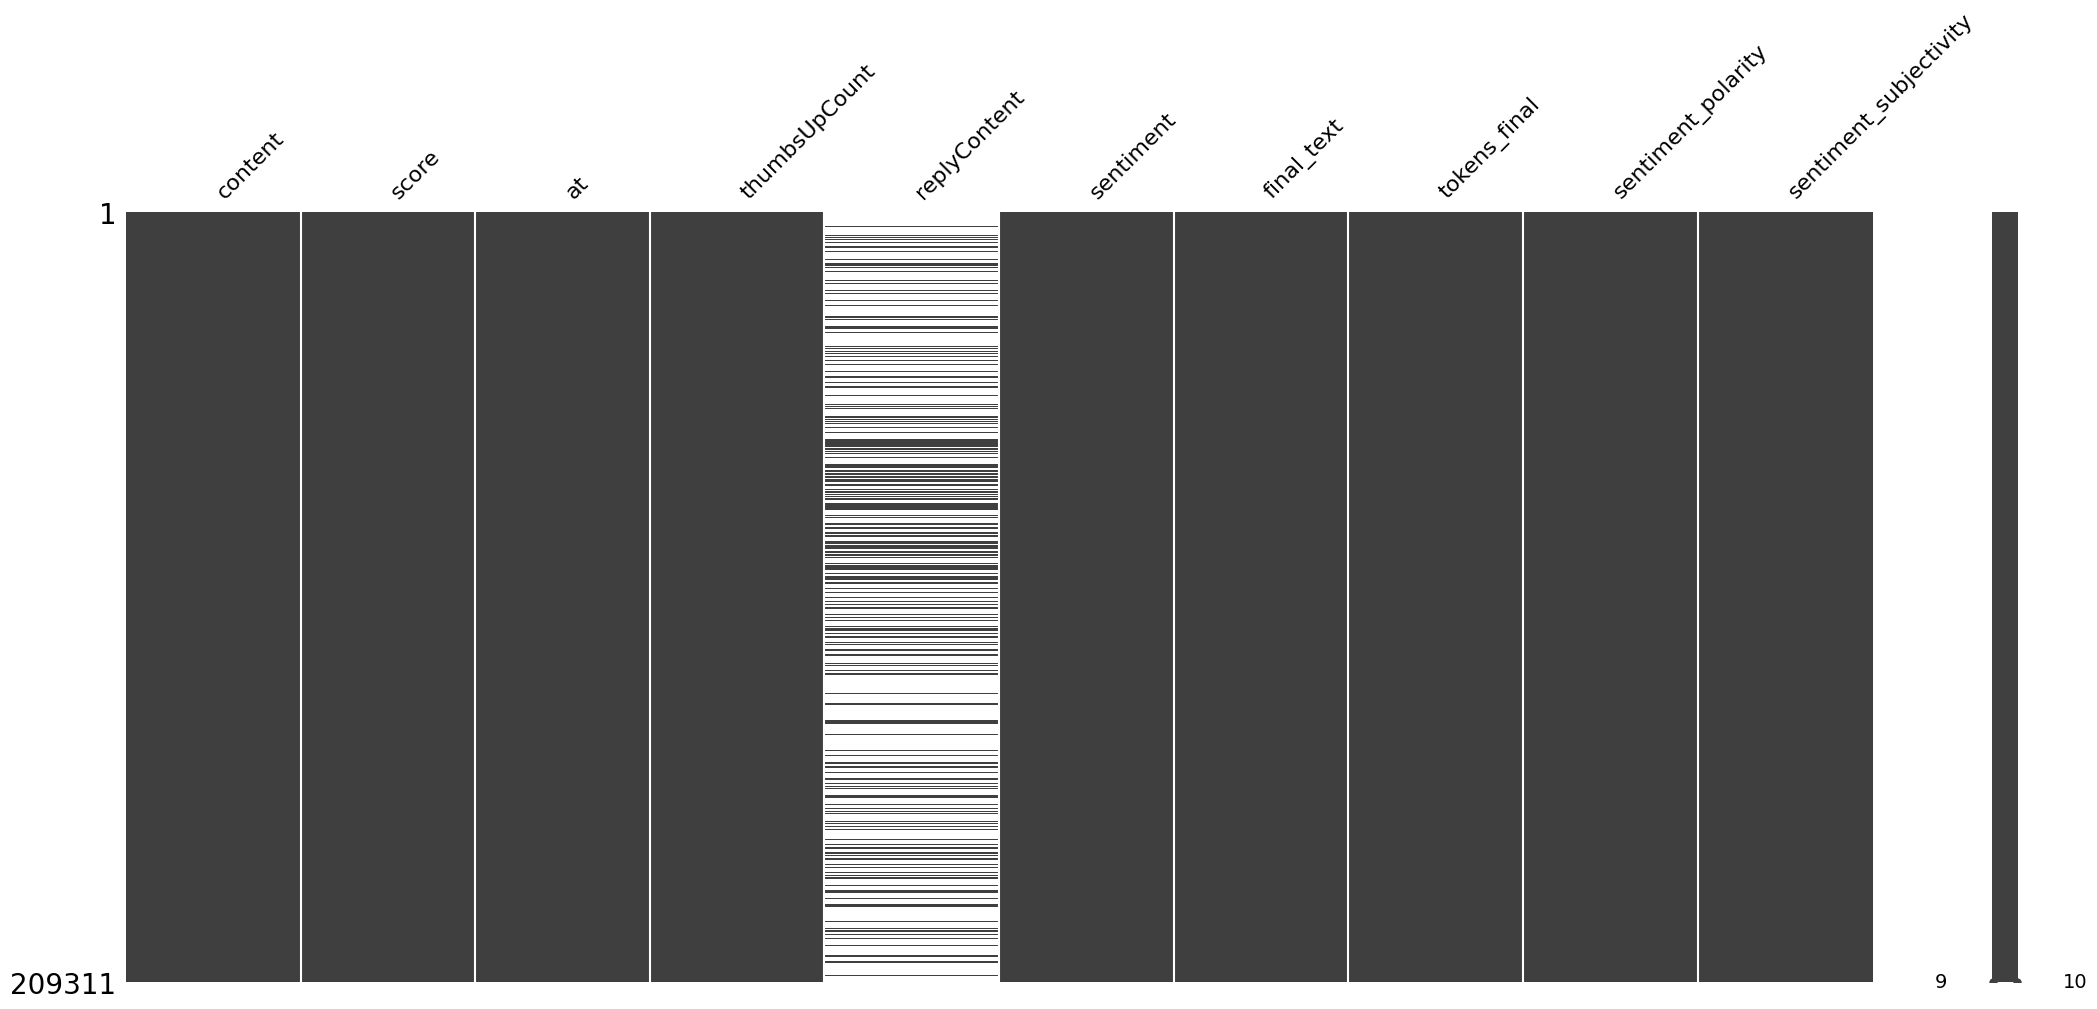

In [12]:
import missingno as msno
msno.matrix(df_gopay_clean)
plt.show()

In [13]:
df_gopay_clean['at'] = pd.to_datetime(df_gopay_clean['at'])
df_gopay_clean['year'] = df_gopay_clean['at'].dt.year

df_selected = df_gopay_clean[['content', 'final_text', 'score', 'sentiment', 'at', 'year']]
df_selected.head()

,content,final_text,score,sentiment,at,year
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",pakai kayak top brimo ket sukses akun saldo ma...,1,negative,2026-02-28 15:16:28,2026
1,busuk,busuk,1,negative,2026-02-28 15:14:08,2026
2,selalu dapat bonus,bonus,5,positive,2026-02-28 15:12:17,2026
3,"good, kasih donk promonya",good kasih promonya,5,positive,2026-02-28 15:10:00,2026
4,terbaik mendukung bwnget,baik dukung,5,positive,2026-02-28 15:08:01,2026


### Scatter Plot: Polarity vs Subjectivity

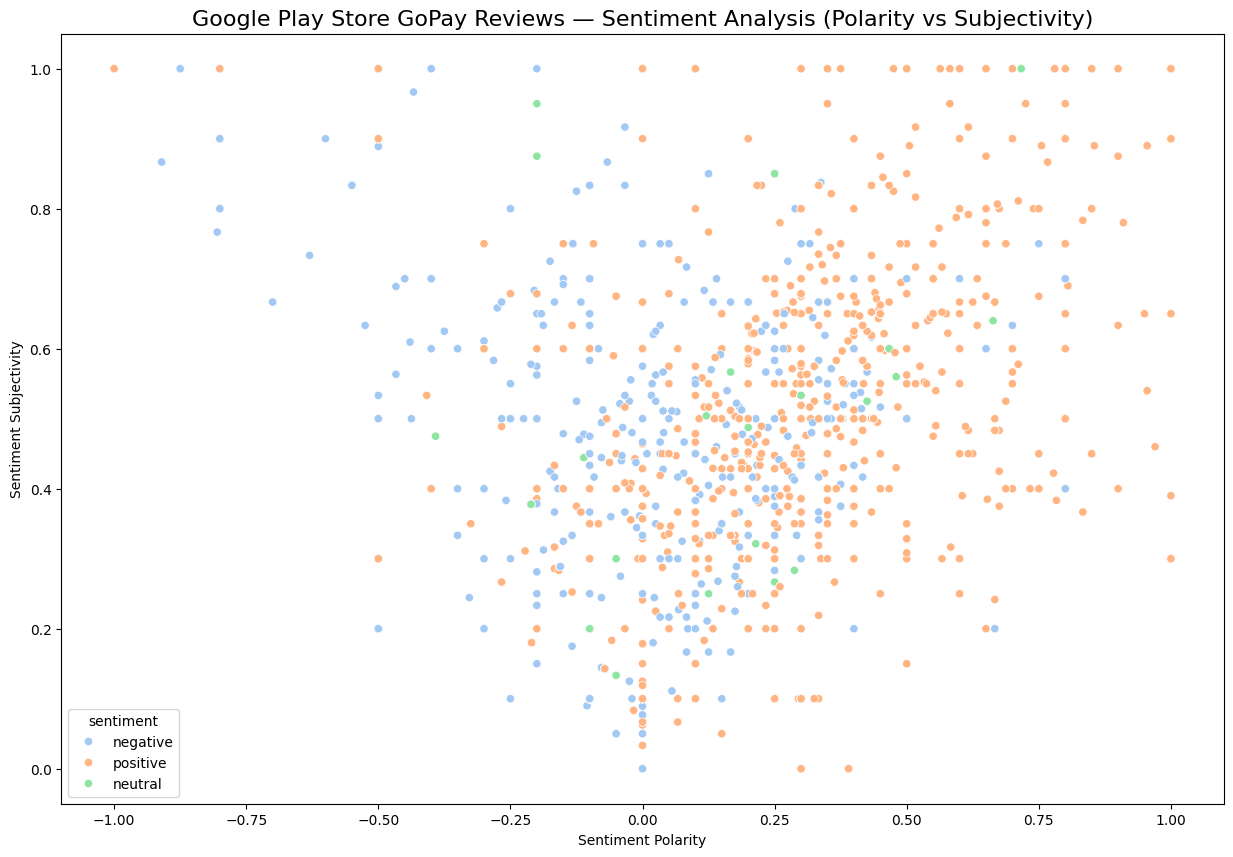

In [14]:
plt.figure(figsize=(15, 10))
sns.scatterplot(
    x=df_gopay_clean['sentiment_polarity'],
    y=df_gopay_clean['sentiment_subjectivity'],
    hue=df_gopay_clean['sentiment'],
    edgecolor='white',
    palette='pastel'
)
plt.title('Google Play Store GoPay Reviews — Sentiment Analysis (Polarity vs Subjectivity)', fontsize=16)
plt.xlabel('Sentiment Polarity')
plt.ylabel('Sentiment Subjectivity')
plt.show()

### Fungsi: Most Frequent Words

In [15]:
from nltk.probability import FreqDist
import nltk
nltk.download('punkt', quiet=True)

def freq_words(x, terms=30):
    all_words = ' '.join([str(text) for text in x if isinstance(text, str)])
    all_words = all_words.split()
    fdist = FreqDist(all_words)
    words_df = pd.DataFrame({'word': list(fdist.keys()), 'count': list(fdist.values())})
    d = words_df.nlargest(columns='count', n=terms)
    plt.figure(figsize=(20, 5))
    ax = sns.barplot(data=d, x='word', y='count', palette='rainbow')
    ax.set(ylabel='Count')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top {terms} Most Frequent Words')
    plt.tight_layout()
    plt.show()

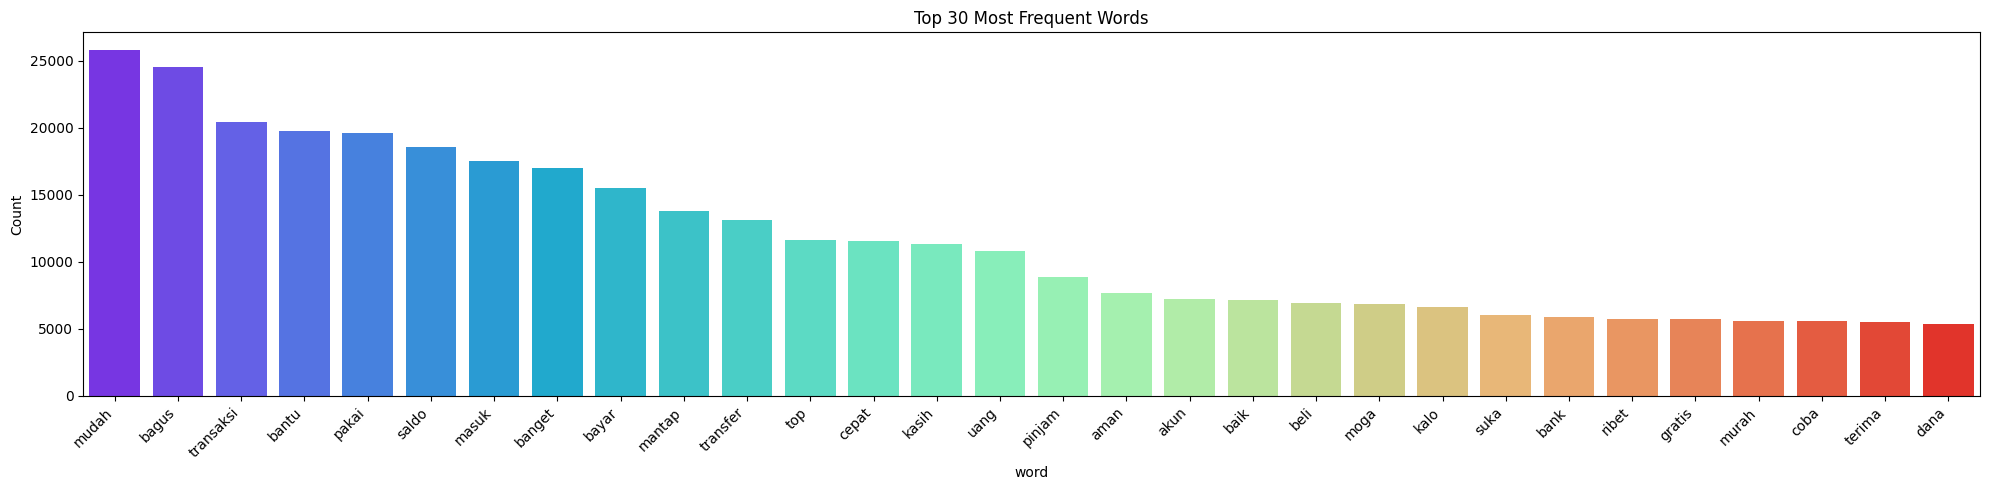

In [16]:
freq_words(df_gopay_clean['final_text'])

### Word Cloud — All Reviews

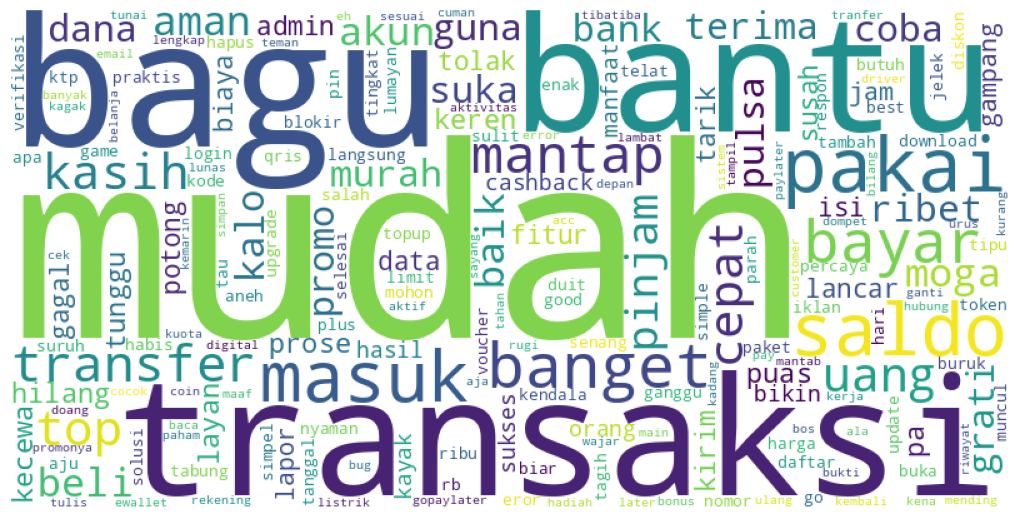

In [17]:
all_text = ' '.join(df_gopay_clean['final_text'].dropna().astype(str))

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    collocations=False
).generate(all_text)

plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

### Word Cloud — Positive vs Negative

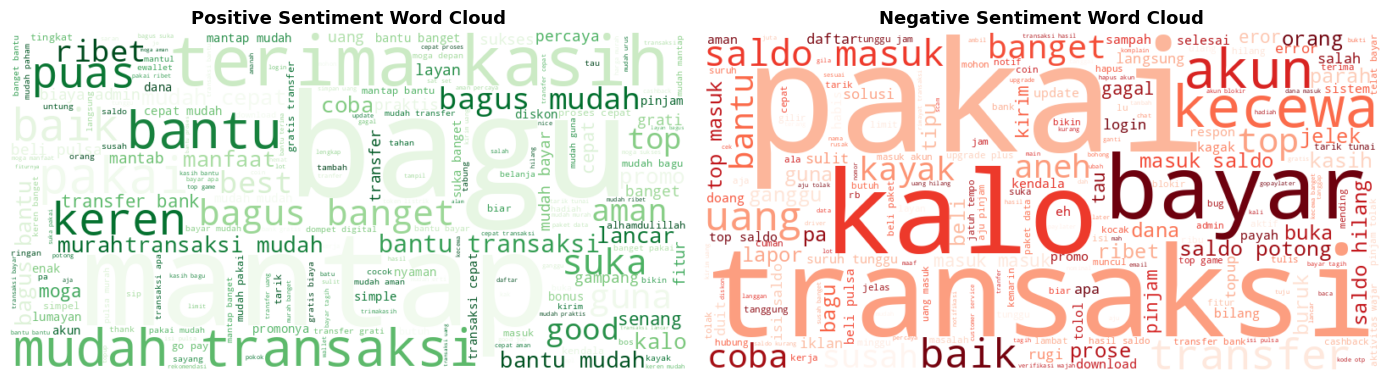

In [18]:
positive_reviews = df_gopay_clean[df_gopay_clean['sentiment'] == 'positive']['final_text'].astype(str)
negative_reviews = df_gopay_clean[df_gopay_clean['sentiment'] == 'negative']['final_text'].astype(str)

positive_wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(' '.join(positive_reviews))
negative_wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(' '.join(negative_reviews))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(positive_wc, interpolation='bilinear')
plt.title('Positive Sentiment Word Cloud', fontsize=13, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_wc, interpolation='bilinear')
plt.title('Negative Sentiment Word Cloud', fontsize=13, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

### Review Count by Year

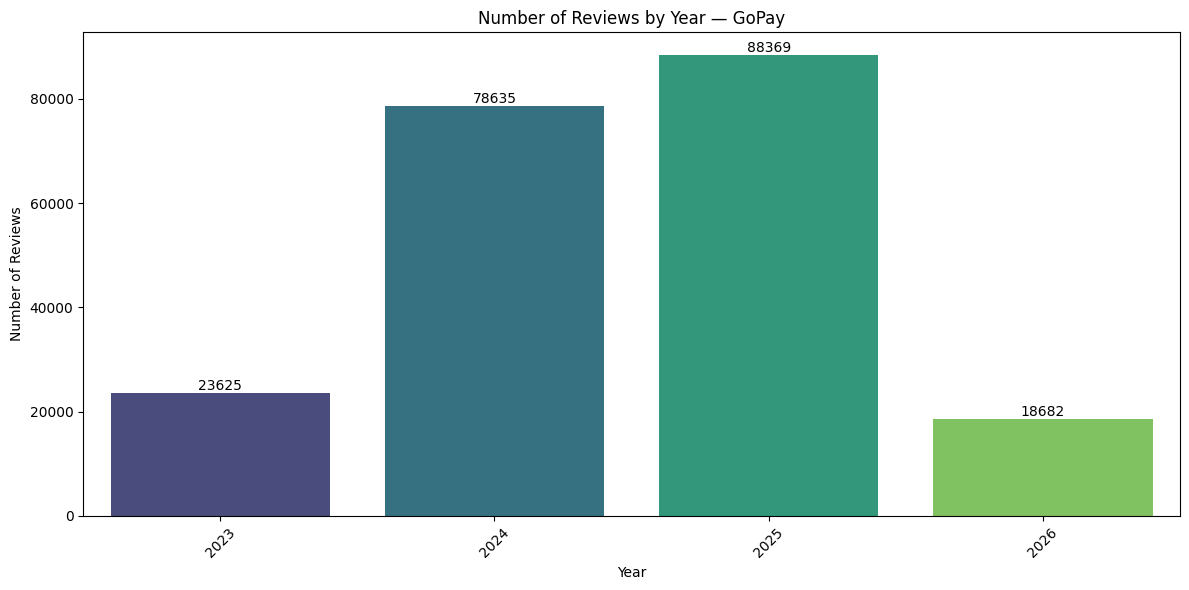

In [19]:
reviews_by_year = df_gopay_clean.groupby('year')['content'].count()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=reviews_by_year.index, y=reviews_by_year.values, palette='viridis')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.title('Number of Reviews by Year — GoPay')
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

### Distribution of Ratings

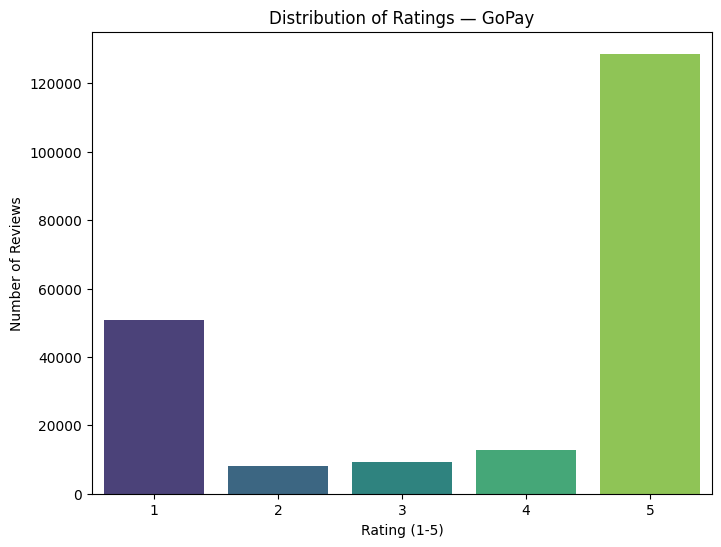

In [20]:
plt.figure(figsize=(8, 6))
sns.countplot(x='score', data=df_gopay_clean, palette='viridis')
plt.title('Distribution of Ratings — GoPay')
plt.xlabel('Rating (1-5)')
plt.ylabel('Number of Reviews')
plt.show()

### Sentiment Trend Over Time (by Year)

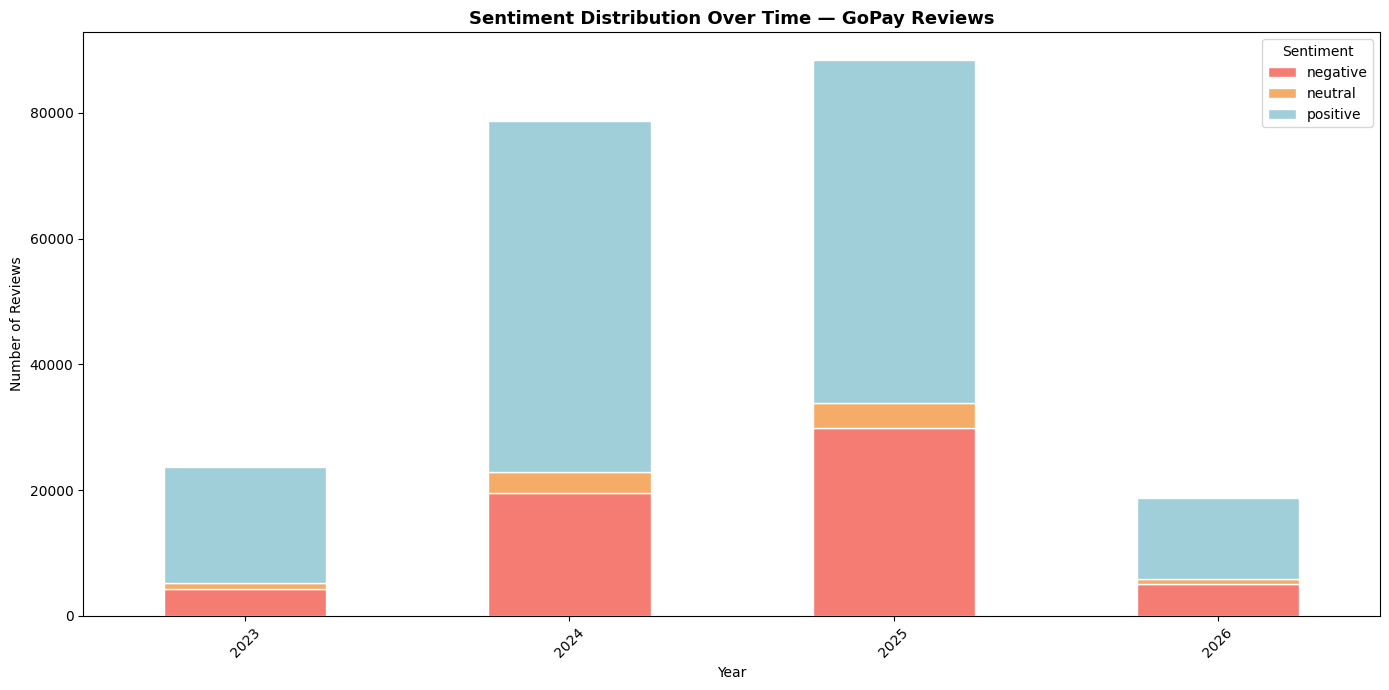

In [21]:
sentiment_over_time = df_gopay_clean.groupby(['year', 'sentiment']).size().unstack(fill_value=0)

sentiment_columns_order = ['negative', 'neutral', 'positive']
for col in sentiment_columns_order:
    if col not in sentiment_over_time.columns:
        sentiment_over_time[col] = 0
sentiment_over_time = sentiment_over_time[sentiment_columns_order]

stacked_bar_colors = {'negative': '#f57c73', 'neutral': '#f6ac69', 'positive': '#a0ced9'}
plot_bar_colors = [stacked_bar_colors[col] for col in sentiment_over_time.columns]

fig, ax = plt.subplots(figsize=(14, 7))
sentiment_over_time.plot(kind='bar', stacked=True, ax=ax,
                          color=plot_bar_colors, edgecolor='white')

ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')
ax.set_title('Sentiment Distribution Over Time — GoPay Reviews', fontsize=13, fontweight='bold')
ax.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Dataset with Sentiment Scores

In [22]:
output_path = '/content/drive/MyDrive/Tugas 1/Dataset/gopay_reviews_sentiment.csv'
df_gopay_clean.to_csv(output_path, index=False)

print(f'Dataset saved: {output_path}')
print(f'Shape: {df_gopay_clean.shape}')
df_gopay_clean.head()

Dataset saved: /content/drive/MyDrive/Tugas 1/Dataset/gopay_reviews_sentiment.csv
Shape: (209311, 11)


,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_final,sentiment_polarity,sentiment_subjectivity,year
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,2026-02-28 15:16:28,0,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",negative,pakai kayak top brimo ket sukses akun saldo ma...,"['pakai', 'kayak', 'top', 'brimo', 'ket', 'suk...",0.5,0.5,2026
1,busuk,1,2026-02-28 15:14:08,0,NaN,negative,busuk,['busuk'],0.0,0.0,2026
2,selalu dapat bonus,5,2026-02-28 15:12:17,0,NaN,positive,bonus,['bonus'],0.0,0.0,2026
3,"good, kasih donk promonya",5,2026-02-28 15:10:00,0,NaN,positive,good kasih promonya,"['good', 'kasih', 'promonya']",0.7,0.6,2026
4,terbaik mendukung bwnget,5,2026-02-28 15:08:01,0,NaN,positive,baik dukung,"['baik', 'dukung']",0.0,0.0,2026
